# 流媒体
LangGraph 实施了流媒体系统来显示实时更新，从而实现响应迅速且透明的用户体验。

LangGraph 的流式传输系统可让您将图形运行的实时反馈显示到您的应用中。
您可以流式传输的数据主要有三类：

- 工作流进度——执行每个图形节点后获取状态更新。
- LLM 标记— 流式传输语言模型标记。
- 自定义更新——发出用户定义的信号（例如，“获取 10/100 条记录”）。

## LangGraph 流式传输有何潜力¶
- [Stream LLM tokens](https://langchain-ai.github.io/langgraph/how-tos/streaming/#messages)——从任何地方捕获令牌流：内部节点、子图或工具。
- [Emit progress notifications from tools](https://langchain-ai.github.io/langgraph/how-tos/streaming/#stream-custom-data)——直接从工具功能发送自定义更新或进度信号。
- [Stream from subgraphs](https://langchain-ai.github.io/langgraph/how-tos/streaming/#stream-subgraph-outputs)——包括来自父图和任何嵌套子图的输出。
- [Use any LLM](https://langchain-ai.github.io/langgraph/how-tos/streaming/#use-with-any-llm) — 从任何 LLM 流出令牌，即使它不是使用custom流模式的 LangChain 模型。
- [Use multiple streaming modes](https://langchain-ai.github.io/langgraph/how-tos/streaming/#stream-multiple-modes)- 从values（完整状态）、updates（状态增量）、messages（LLM 令牌 + 元数据）、custom（任意用户数据）或debug（详细跟踪）中选择

# 流输出
您可以从 LangGraph 代理或工作流中流式输出。

支持的流模式

将以下一个或多个流模式作为列表传递给`stream()`或`astream()`方法：

| 模式 | 描述 |
| :--- | :--- |
| values | 在图的每个步骤之后流式传输状态的完整值。 |
| updates | 将图的每个步骤之后的更新流式传输到状态。如果在同一步骤中进行了多个更新（例如，运行了多个节点），则这些更新将分别流式传输。 |
| custom | 从图形节点内部流式传输自定义数据。 |
| messages | 从调用 LLM 的任何图形节点流式传输 2 元组（LLM 令牌、元数据）。 |
| debug | 在整个图表执行过程中传输尽可能多的信息。 |



## 来自代理的流¶
### 代理进度
要流式传输代理进度，请将stream()或astream()方法与 结合使用stream_mode="updates"。这将在代理每个步骤后发出一个事件。

例如，如果您有一个调用工具一次的代理，您应该会看到以下更新：

- LLM 节点：带有工具调用请求的 AI 消息
- 工具节点：带有执行结果的工具消息
- LLM 节点：最终 AI 响应


In [4]:
from langchain.chat_models import init_chat_model
from langgraph.prebuilt import create_react_agent
from dotenv import load_dotenv
import os
load_dotenv()  # 加载环境变量


# 这个代理将模拟一个天气查询功能，返回指定城市的天气信息。
def get_weather(city: str) -> str:  
    """Get weather for a given city."""
    return f" {city} 天气晴天，温度 25°C."

agent = create_react_agent(
    model="openai:o4-mini",
    tools=[get_weather],
)
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]},
    stream_mode="updates"
):
    print(chunk)
    print("\n")

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_F3RtIQAj0yiY7NMuXoVSi3jB', 'function': {'arguments': '{"city":"San Francisco"}', 'name': 'get_weather'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 214, 'prompt_tokens': 50, 'total_tokens': 264, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'o4-mini', 'system_fingerprint': None, 'id': 'chatcmpl-ByT2jLZotV8JNI9ZLQx4qZumWMmmj', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--ac07a4ed-5c37-4379-9120-2d667960ee86-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'San Francisco'}, 'id': 'call_F3RtIQAj0yiY7NMuXoVSi3jB', 'type': 'tool_call'}], usage_metadata={'input_tokens': 50, 'output_tokens': 214, 'total_tokens': 264, 'input_token_details': {'audio': 0, 'c

## LLM token
要流式传输由 LLM 生成的token，请使用`stream_mode="messages"`：

In [6]:
agent = create_react_agent(
    model="openai:o4-mini",
    tools=[get_weather],
)
for token, metadata in agent.stream(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]},
    stream_mode="messages"
):
    print("Token", token)
    print("Metadata", metadata)
    print("\n")

Token content='' additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_0K1Pu4dXD06Rv8QxXfuY1zH2', 'function': {'arguments': '', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={} id='run--a437cead-d19d-4314-a0c0-ef44f5423179' tool_calls=[{'name': 'get_weather', 'args': {}, 'id': 'call_0K1Pu4dXD06Rv8QxXfuY1zH2', 'type': 'tool_call'}] tool_call_chunks=[{'name': 'get_weather', 'args': '', 'id': 'call_0K1Pu4dXD06Rv8QxXfuY1zH2', 'index': 0, 'type': 'tool_call_chunk'}]
Metadata {'langgraph_step': 1, 'langgraph_node': 'agent', 'langgraph_triggers': ('branch:to:agent',), 'langgraph_path': ('__pregel_pull', 'agent'), 'langgraph_checkpoint_ns': 'agent:7c30c11e-9805-e9f3-1d26-b4fecef9d4e6', 'checkpoint_ns': 'agent:7c30c11e-9805-e9f3-1d26-b4fecef9d4e6', 'ls_provider': 'openai', 'ls_model_name': 'o4-mini', 'ls_model_type': 'chat', 'ls_temperature': None}


Token content='' additional_kwargs={'tool_calls': [{'index': 0, 'id': None, 'function': {'arguments': '{"', 'name': None}, 

In [ ]:
agent = create_react_agent(
    model="anthropic:claude-3-7-sonnet-latest",
    tools=[get_weather],
)
async for token, metadata in agent.astream(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]},
    stream_mode="messages"
):
    print("Token", token)
    print("Metadata", metadata)
    print("\n")



###  工具更新¶
要在工具执行时从工具中流式传输更新，您可以使用[get_stream_writer](https://langchain-ai.github.io/langgraph/reference/config/#langgraph.config.get_stream_writer)。

In [8]:
from langgraph.config import get_stream_writer

def get_weather(city: str) -> str:
    """Get weather for a given city."""
    writer = get_stream_writer()
    # stream any arbitrary data
    writer(f"Looking up data for city: {city}")
    return f"It's always sunny in {city}!"

agent = create_react_agent(
    model="openai:o4-mini",
    tools=[get_weather],
)

for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]},
    stream_mode="custom"
):
    print(chunk)
    print("\n")

Looking up data for city: San Francisco




### 流多种模式
您可以通过将流模式作为列表传递来指定多种流模式`stream_mode=["updates", "messages", "custom"]`：：



In [10]:
agent = create_react_agent(
    model="openai:o4-mini",
    tools=[get_weather],
)

for stream_mode, chunk in agent.stream(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]},
    stream_mode=["updates", "messages", "custom"]
):
    print(chunk)
    print("\n")

(AIMessageChunk(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_10hFqmGIU2O42DhUXWaPX1lD', 'function': {'arguments': '', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={}, id='run--5a8542c3-3662-4e4a-b200-4af5dbc58c1d', tool_calls=[{'name': 'get_weather', 'args': {}, 'id': 'call_10hFqmGIU2O42DhUXWaPX1lD', 'type': 'tool_call'}], tool_call_chunks=[{'name': 'get_weather', 'args': '', 'id': 'call_10hFqmGIU2O42DhUXWaPX1lD', 'index': 0, 'type': 'tool_call_chunk'}]), {'langgraph_step': 1, 'langgraph_node': 'agent', 'langgraph_triggers': ('branch:to:agent',), 'langgraph_path': ('__pregel_pull', 'agent'), 'langgraph_checkpoint_ns': 'agent:fd0fa335-0202-a4b0-0e5f-199a91787f09', 'checkpoint_ns': 'agent:fd0fa335-0202-a4b0-0e5f-199a91787f09', 'ls_provider': 'openai', 'ls_model_name': 'o4-mini', 'ls_model_type': 'chat', 'ls_temperature': None})


(AIMessageChunk(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': None, 'function': {'arguments': '

## 禁用流媒体¶
在某些应用中，你可能需要禁用给定模型中单个 token 的流式传输。这在[多智能体](https://langchain-ai.github.io/langgraph/agents/multi-agent/)系统中很有用，可以控制哪些智能体可以流式传输其输出。

请参阅[模型](https://langchain-ai.github.io/langgraph/agents/models/#disable-streaming)指南以了解如何禁用流式传输。

## 来自工作流的流¶

### 基本使用示例

LangGraph 图公开`.stream()(sync)` 和`.astream()(async)` 方法以产生流输出作为迭代器。



In [11]:
for chunk in graph.stream(inputs, stream_mode="updates"):
    print(chunk)

NameError: name 'graph' is not defined

### 流图状态¶
使用流模式updates并values在图表执行时流式传输其状态。

updates在图的每个步骤之后将更新流式传输到状态。

values在图的每个步骤之后流式传输状态的完整值。

In [12]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
  topic: str
  joke: str


def refine_topic(state: State):
    return {"topic": state["topic"] + " and cats"}


def generate_joke(state: State):
    return {"joke": f"This is a joke about {state['topic']}"}

graph = (
  StateGraph(State)
  .add_node(refine_topic)
  .add_node(generate_joke)
  .add_edge(START, "refine_topic")
  .add_edge("refine_topic", "generate_joke")
  .add_edge("generate_joke", END)
  .compile()
)

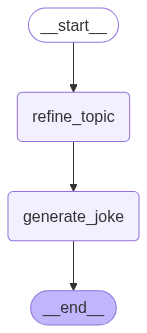

In [13]:
graph

使用此选项仅流式传输节点在每个步骤后返回的状态更新。流式输出包含节点名称以及更新内容。

1. update

In [14]:
for chunk in graph.stream(
    {"topic": "ice cream"},
    stream_mode="updates",
):
    print(chunk)

{'refine_topic': {'topic': 'ice cream and cats'}}
{'generate_joke': {'joke': 'This is a joke about ice cream and cats'}}


使用此功能在每个步骤之后传输图表的完整状态。 

2. values

In [15]:
for chunk in graph.stream(
    {"topic": "ice cream"},
    stream_mode="values",
):
    print(chunk)

{'topic': 'ice cream'}
{'topic': 'ice cream and cats'}
{'topic': 'ice cream and cats', 'joke': 'This is a joke about ice cream and cats'}


### 调试¶
使用debug流模式在图表执行过程中尽可能多地传输信息。流输出包括节点名称以及完整状态。

In [16]:
for chunk in graph.stream(
    {"topic": "ice cream"},
    stream_mode="debug",
):
    print(chunk)

{'step': 1, 'timestamp': '2025-07-29T01:36:03.423303+00:00', 'type': 'task', 'payload': {'id': '8bdfc215-0024-ba61-4342-8f4d98f01f3b', 'name': 'refine_topic', 'input': {'topic': 'ice cream'}, 'triggers': ('branch:to:refine_topic',)}}
{'step': 1, 'timestamp': '2025-07-29T01:36:03.423438+00:00', 'type': 'task_result', 'payload': {'id': '8bdfc215-0024-ba61-4342-8f4d98f01f3b', 'name': 'refine_topic', 'error': None, 'result': [('topic', 'ice cream and cats')], 'interrupts': []}}
{'step': 2, 'timestamp': '2025-07-29T01:36:03.423515+00:00', 'type': 'task', 'payload': {'id': '72235f9e-0194-a60f-a170-12b01fe963f9', 'name': 'generate_joke', 'input': {'topic': 'ice cream and cats'}, 'triggers': ('branch:to:generate_joke',)}}
{'step': 2, 'timestamp': '2025-07-29T01:36:03.423612+00:00', 'type': 'task_result', 'payload': {'id': '72235f9e-0194-a60f-a170-12b01fe963f9', 'name': 'generate_joke', 'error': None, 'result': [('joke', 'This is a joke about ice cream and cats')], 'interrupts': []}}


## LLM token
使用流模式从图的任何部分（包括节点、工具、子图或任务）逐个标记地流式`messages`传输大型语言模型 `(LLM) 输出`。

> 如果您的 LLM 不支持 LangChain 集成，您可以使用custom模式来流式传输其输出。详情请参阅与任意 LLM 的结合使用。

> 当使用 Python 3.11 以下版本进行异步代码时，必须显式传入RunnableConfig以ainvoke()启用正确的流式传输。有关详细信息，请参阅Python 3.11 以下版本的异步，或升级到 Python 3.11 及以上版本。

In [17]:
from dataclasses import dataclass

from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START


@dataclass
class MyState:
    topic: str
    joke: str = ""


llm = init_chat_model(model="openai:gpt-4o-mini")

def call_model(state: MyState):
    """Call the LLM to generate a joke about a topic"""
    llm_response = llm.invoke( 
        [
            {"role": "user", "content": f"Generate a joke about {state.topic}"}
        ]
    )
    return {"joke": llm_response.content}

graph = (
    StateGraph(MyState)
    .add_node(call_model)
    .add_edge(START, "call_model")
    .compile()
)

for message_chunk, metadata in graph.stream( 
    {"topic": "ice cream"},
    stream_mode="messages",
):
    if message_chunk.content:
        print(message_chunk.content, end="|", flush=True)

Why| did| the| ice| cream| cone| break| up| with| the| sund|ae|?|  

|Because| it| found| someone| who| was| a| little| more| "|ch|ill|!"| 🍦|😄|

## 按 LLM 调用进行过滤¶
您可以tags与 LLM 调用关联，以通过 LLM 调用过滤流式令牌。

In [ ]:
from langchain.chat_models import init_chat_model

llm_1 = init_chat_model(model="openai:gpt-4o-mini", tags=['joke']) 
llm_2 = init_chat_model(model="openai:gpt-4o-mini", tags=['poem']) 

graph = ... # define a graph that uses these LLMs

async for msg, metadata in graph.astream(  
    {"topic": "cats"},
    stream_mode="messages",
):
    if metadata["tags"] == ["joke"]: 
        print(msg.content, end="|", flush=True)

### 按节点过滤¶
要仅从特定节点流式传输令牌，请使用流元数据中`stream_mode="messages"`的字段并过滤输出`：langgraph_node`

In [ ]:
for msg, metadata in graph.stream( 
    inputs,
    stream_mode="messages",
):
    if msg.content and metadata["langgraph_node"] == "some_node_name": 
        ...

## 流式传输自定义数据¶
要从 LangGraph 节点或工具内部发送自定义用户定义数据，请按照以下步骤操作：

- 用于`get_stream_writer()`访问流写入器并发出自定义数据。
- `stream_mode="custom"`调用`.stream()`或时设置，`.astream()`用于获取流中的自定义数据。您可以组合多种模式（例如`["updates", "custom"]`），但至少必须有一种`"custom"`。



In [ ]:
from typing import TypedDict
from langgraph.config import get_stream_writer
from langgraph.graph import StateGraph, START

class State(TypedDict):
    query: str
    answer: str

def node(state: State):
    writer = get_stream_writer()  
    writer({"custom_key": "Generating custom data inside node"}) 
    return {"answer": "some data"}

graph = (
    StateGraph(State)
    .add_node(node)
    .add_edge(START, "node")
    .compile()
)

inputs = {"query": "example"}

# Usage
for chunk in graph.stream(inputs, stream_mode="custom"):  
    print(chunk)

In [ ]:
from langchain_core.tools import tool
from langgraph.config import get_stream_writer

@tool
def query_database(query: str) -> str:
    """Query the database."""
    writer = get_stream_writer() 
    writer({"data": "Retrieved 0/100 records", "type": "progress"}) 
    # perform query
    writer({"data": "Retrieved 100/100 records", "type": "progress"}) 
    return "some-answer" 


graph = ... # define a graph that uses this tool

for chunk in graph.stream(inputs, stream_mode="custom"): 
    print(chunk)

## 与任何 LLM 一起使用

您可以使用 `stream_mode="custom"`（自定义）从任何 LLM API 流式传输数据，即使该 API 没有实现 LangChain 聊天模型接口。

这使您可以集成提供其自己的流接口的原始 LLM 客户端或外部服务，从而使 LangGraph 具有高度灵活的自定义设置能力。


In [ ]:
from langgraph.config import get_stream_writer

def call_arbitrary_model(state):
    """Example node that calls an arbitrary model and streams the output"""
    writer = get_stream_writer() 
    # Assume you have a streaming client that yields chunks
    for chunk in your_custom_streaming_client(state["topic"]): 
        writer({"custom_llm_chunk": chunk}) 
    return {"result": "completed"}

graph = (
    StateGraph(State)
    .add_node(call_arbitrary_model)
    # Add other nodes and edges as needed
    .compile()
)

for chunk in graph.stream(
    {"topic": "cats"},
    stream_mode="custom", 
):
    # The chunk will contain the custom data streamed from the llm
    print(chunk)

## 禁用特定聊天模型的流式传输¶
如果您的应用程序将支持流式传输的模型与不支持流式传输的模型混合使用，则可能需要明确禁用不支持流式传输的模型。

初始化模型时设置`disable_streaming=True`。

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    "anthropic:claude-3-7-sonnet-latest",
    disable_streaming=True 
)

## 与 Python < 3.11 异步¶
在 Python 3.11 以下版本中，asyncio 任务不支持该context参数。
这限制了 LangGraph 自动传播上下文的能力，并从两个关键方面影响了 LangGraph 的流式传输机制：

- 您必须明确传递`RunnableConfig`异步 LLM 调用（例如ainvoke()），因为回调不会自动传播。
- 您不能`get_stream_writer()`在异步节点或工具中使用- 您必须writer直接传递参数。

# 流式 API

LangGraph SDK允许您从 LangGraph API 服务器流式传输输出。

## 基本用法¶
基本用法示例：



In [ ]:
from langgraph_sdk import get_client
client = get_client(url=<DEPLOYMENT_URL>, api_key=<API_KEY>)

# Using the graph deployed with the name "agent"
assistant_id = "agent"

# create a thread
thread = await client.threads.create()
thread_id = thread["thread_id"]

# create a streaming run
async for chunk in client.runs.stream(
    thread_id,
    assistant_id,
    input=inputs,
    stream_mode="updates"
):
    print(chunk.data)

## 支持的流模式

| 模式 | 描述 |  LangGraph 库方法 |
| :--- | :--- |:--- |
| values | 在每个超级步骤之后流式传输完整的图形状态。 | `.stream()`/`.astream()`和`stream_mode="values"` |
| updates | 	将图的每个步骤之后的更新流式传输到状态。如果在同一步骤中进行了多个更新（例如，运行了多个节点），则这些更新将分别流式传输。 | `.stream()`/`.astream()`和`stream_mode="updates"`|
| messages-tuple | 为调用 LLM 的图形节点流式传输 LLM 令牌和元数据（对于聊天应用程序很有用）。 | `.stream()`/`.astream()`和`stream_mode="messages"`|
| debug | 在整个图表执行过程中传输尽可能多的信息。（LLM 令牌、元数据）。 | `.stream()`/`.astream()`和`stream_mode="debug"` |
| custom | 从图表内部流式传输自定义数据 | `.stream()`/`.astream()`和`stream_mode="custom"` |
| events | 流式传输所有事件（包括图表的状态）；主要在迁移大型 LCEL 应用程序时有用。 | `.astream_events()` |

## 流式传输多种模式 
您可以将一个列表作为 `stream_mode` 参数传递，以同时串流多种模式。 流式输出将是 `(mode, chunk)` 的元组，其中 `mode `是流模式的名称，`chunk` 是该模式流式传输的数据。

In [ ]:
async for chunk in client.runs.stream(
    thread_id,
    assistant_id,
    input=inputs,
    stream_mode=["updates", "custom"]
):
    print(chunk)

## 流图状态¶
使用流模式updates并values在图表执行时流式传输其状态。

- updates在图的每个步骤之后将更新流式传输到状态。
- values在图的每个步骤之后流式传输状态的完整值。

In [ ]:
from langgraph_sdk import get_client
client = get_client(url=<DEPLOYMENT_URL>)

# Using the graph deployed with the name "agent"
assistant_id = "agent"
# create a thread
thread = await client.threads.create()
thread_id = thread["thread_id"]



使用此选项仅流式传输节点在每个步骤后返回的状态更新。流式输出包含节点名称以及更新内容。

In [ ]:
async for chunk in client.runs.stream(
    thread_id,
    assistant_id,
    input={"topic": "ice cream"},
    stream_mode="updates"
):
    print(chunk.data)




## 子图¶
要将子图的输出包含在流输出中，您可以在父图的方法`subgraphs=True`中进行设置`.stream()`。这将同时从父图和任何子图流输出。

In [ ]:
for chunk in client.runs.stream(
    thread_id,
    assistant_id,
    input={"foo": "foo"},
    stream_subgraphs=True, 
    stream_mode="updates",
):
    print(chunk)

## 调试¶
使用`debug`流模式在图表执行过程中尽可能多地传输信息。流输出包括节点名称以及完整状态。

In [ ]:
async for chunk in client.runs.stream(
    thread_id,
    assistant_id,
    input={"topic": "ice cream"},
    stream_mode="debug"
):
    print(chunk.data)

### LLM token¶
使用流模式从图的任何部分（包括节点、工具、子图或任务）逐个标记地流式messages-tuple传输大型语言模型 (LLM) 输出。

`messages-tuple`模式的流输出是一个元组(`message_chunk`, `metadata`)，其中：

- `message_chunk`：来自 LLM 的标记或消息段。
- `metadata`：包含有关图形节点和 LLM 调用的详细信息的字典。

In [ ]:
async for chunk in client.runs.stream(
    thread_id,
    assistant_id,
    input={"topic": "ice cream"},
    stream_mode="messages-tuple",
):
    if chunk.event != "messages":
        continue

    message_chunk, metadata = chunk.data  
    if message_chunk["content"]:
        print(message_chunk["content"], end="|", flush=True)

### 过滤 LLM 令牌¶
- 要通过 LLM 调用过滤流式标记，您可以将其与 LLM 调用关联tags。
- 要只对特定节点的标记进行流式处理，请使用 `stream_mode="messages"`，并根据流式元数据中的 `langgraph_node` 字段过滤输出。

## 流式传输自定义数据¶
发送自定义用户定义数据：

In [ ]:
async for chunk in client.runs.stream(
    thread_id,
    assistant_id,
    input={"query": "example"},
    stream_mode="custom"
):
    print(chunk.data)

## 流事件¶
要流式传输所有事件，包括图表的状态：

In [ ]:
async for chunk in client.runs.stream(
    thread_id,
    assistant_id,
    input={"topic": "ice cream"},
    stream_mode="events"
):
    print(chunk.data)

## 无状态运行¶
如果您不想将流运行的输出保留在检查点数据库中，则可以创建无状态运行而不创建线程：

In [ ]:
from langgraph_sdk import get_client
client = get_client(url=<DEPLOYMENT_URL>, api_key=<API_KEY>)

async for chunk in client.runs.stream(
    None,  
    assistant_id,
    input=inputs,
    stream_mode="updates"
):
    print(chunk.data)

## 加入和流化 
`LangGraph Platform` 允许您加入一个活动的后台运行，并将其输出流化。为此，您可以使用 `LangGraph SDK` 的 `client.runs.join_stream` 方法：

In [ ]:
from langgraph_sdk import get_client
client = get_client(url=<DEPLOYMENT_URL>, api_key=<API_KEY>)

async for chunk in client.runs.join_stream(
    thread_id,
    run_id,  
):
    print(chunk)

## API 参考¶
有关 API 的使用和实现，请参阅[API 参考](https://langchain-ai.github.io/langgraph/cloud/reference/api/api_ref.html#tag/thread-runs/POST/threads/{thread_id}/runs/stream)。